# 04 — Evaluation and Error Analysis

## Metrics
All metrics are reported in **basis points** on the held-out test set
(last 20% of bars — never touched during training or validation).

| Metric | Description |
|--------|-------------|
| MAE    | Mean absolute error — primary metric, directly interpretable |
| RMSE   | Root mean squared error — emphasises large errors |
| MedAE  | Median absolute error — robust to outliers |

## Baselines
1. **Mean predictor** — always predicts training-set mean slippage
2. **Linear (Ridge)** — same features, linear model
3. **Heuristic** — β × order_size_fraction × vol_rolling, β calibrated on val

## Error analysis segments
Order size (Q1–Q4) · Volatility (Q1–Q4) · Time of day (open/mid/close) · Buy vs sell · Volume regime

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

from features import FEATURE_NAMES_TRAINING
from pipeline import build_full_dataset
from model import SlippageMLP
from train import predict
from baselines import MeanPredictor, LinearBaseline, HeuristicBaseline
from evaluate import global_metrics, segment_breakdown, evaluate_all
from paths import RESULTS_DIR
from viz import (
    plot_pred_vs_actual,
    plot_error_by_segment,
    plot_feature_importance,
    FIGURES_DIR,
)

In [2]:
# Rebuild data and split via the shared pipeline. split.test_df is
# guaranteed to align row-by-row with split.y_test / X_test.
data, proxy_all, split = build_full_dataset()
n_tr, n_v, n_te = len(split.X_train), len(split.X_val), len(split.X_test)
print(f'Train: {n_tr:,}  Val: {n_v:,}  Test: {n_te:,}')

test_df = split.test_df  # no more iloc tricks

[data] SPY: 3432 bars (2024-06-04 → 2026-05-22)
[data] QQQ: 3414 bars (2024-06-04 → 2026-05-22)
[data] AAPL: 3426 bars (2024-06-04 → 2026-05-22)
[data] MSFT: 3426 bars (2024-06-04 → 2026-05-22)
[data] NVDA: 3424 bars (2024-06-04 → 2026-05-22)
[data] AMZN: 3433 bars (2024-06-04 → 2026-05-22)
[data] GOOGL: 3431 bars (2024-06-04 → 2026-05-22)
[data] META: 3424 bars (2024-06-04 → 2026-05-22)
[data] JPM: 3434 bars (2024-06-04 → 2026-05-22)
Train: 79,726  Val: 18,398  Test: 24,532


In [3]:
# Load trained model
checkpoint = torch.load(RESULTS_DIR / 'model_checkpoint.pt', weights_only=True)
model = SlippageMLP(n_features=checkpoint['n_features'])
model.load_state_dict(checkpoint['state_dict'])
y_pred_mlp = predict(model, split.X_test)
y_test = split.y_test

In [4]:
# Fit baselines
mean_pred = MeanPredictor().fit(split.X_train, split.y_train)
linear_pred = LinearBaseline().fit(split.X_train, split.y_train)
heuristic = HeuristicBaseline(FEATURE_NAMES_TRAINING)
heuristic.fit(split.X_val, split.y_val, split.scaler.mean_, split.scaler.scale_)

y_pred_mean = mean_pred.predict(split.X_test)
y_pred_linear = linear_pred.predict(split.X_test)
y_pred_heuristic = heuristic.predict(split.X_test, split.scaler.mean_, split.scaler.scale_)

In [5]:
# Full evaluation: saves metrics.json (global + segment_breakdown) and prints summary
results = evaluate_all(
    split,
    model_predict_fn=lambda X: predict(model, X),
    baselines={
        'linear':    lambda X: linear_pred.predict(X),
        'heuristic': lambda X: heuristic.predict(X, split.scaler.mean_, split.scaler.scale_),
        'mean':      lambda X: mean_pred.predict(X),
    },
)
print(f'Full metrics (incl. segment_breakdown) saved to {RESULTS_DIR}/metrics.json\n')

metrics_df = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if kk != 'segment_breakdown'}
    for k, v in results.items()
}).T
print('=== Global Metrics (test set, bps) ===')
print(metrics_df.round(2).to_string())

Full metrics (incl. segment_breakdown) saved to /Users/francesconatale/Documents/projects/slippage-predictor/results/metrics.json

=== Global Metrics (test set, bps) ===
           mae_bps  rmse_bps  med_ae_bps
mlp           4.70      7.24        3.00
linear        6.90     10.07        5.20
heuristic    10.88     16.51        7.02
mean         15.19     21.49       12.61


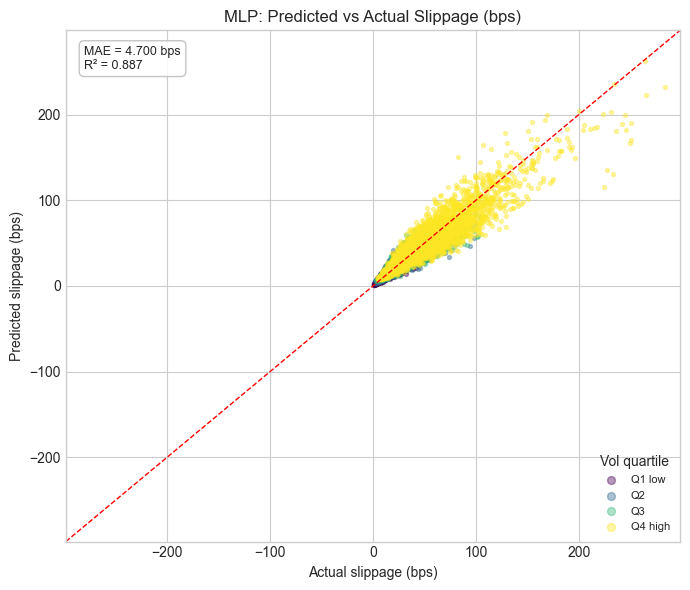

In [6]:
# Predicted vs actual — coloured by vol regime
vol_q = pd.qcut(test_df['vol_rolling'], q=4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
fig = plot_pred_vs_actual(
    y_test, y_pred_mlp,
    regime=vol_q.values,
    regime_label='Vol quartile',
    title='MLP: Predicted vs Actual Slippage (bps)',
    save_as='pred_vs_actual.png',
)
plt.show()

      segment         bucket  n_samples  mae_bps  rmse_bps  med_ae_bps
size_quartile       Q1_small       6133 2.579373  3.964385    1.751732
size_quartile             Q2       6133 4.341381  6.413477    2.972533
size_quartile             Q3       6133 5.427363  7.832237    3.743089
size_quartile       Q4_large       6133 6.452401  9.552846    4.410925
 vol_quartile     Q1_low_vol       6136 2.474157  3.524165    1.711197
 vol_quartile             Q2       6132 3.710480  5.180356    2.725060
 vol_quartile             Q3       6132 4.854703  6.689520    3.558131
 vol_quartile    Q4_high_vol       6132 7.762631 11.201357    5.399752
  time_of_day           open       3528 5.673403  8.833545    3.606295
  time_of_day            mid      17456 4.450424  6.828820    2.886480
  time_of_day          close       3548 4.960882  7.418078    3.221844
         side            buy      12267 4.700278  7.194609    2.994524
         side           sell      12265 4.699981  7.277542    3.003417
volume

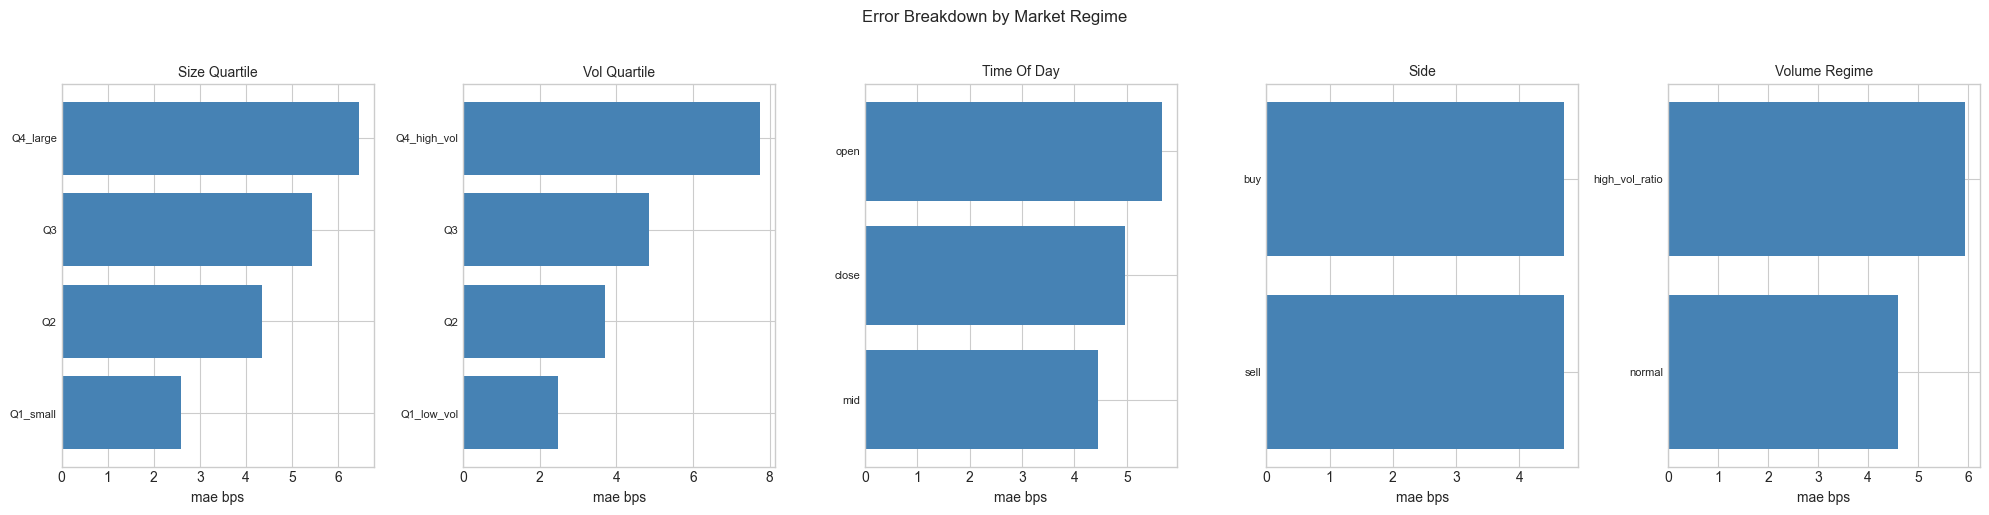

In [7]:
# Error breakdown by segment
breakdown = segment_breakdown(y_test, y_pred_mlp, test_df)
print(breakdown.to_string(index=False))
fig = plot_error_by_segment(breakdown, metric='mae_bps', save_as='error_by_segment.png')
plt.show()

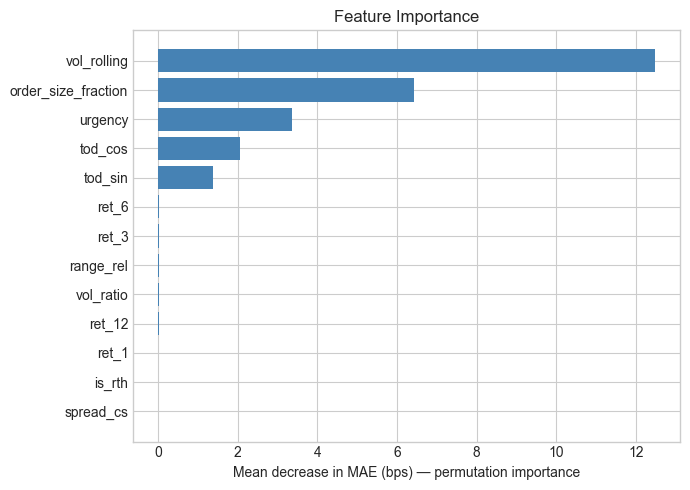

All figures saved to results/figures/


In [8]:
# Feature importance (permutation, on val set)
fig = plot_feature_importance(
    model, split.X_val, split.y_val, FEATURE_NAMES_TRAINING,
    n_repeats=5, seed=42, save_as='feature_importance.png',
)
plt.show()
print('All figures saved to results/figures/')